# Training set optimization

## Plan
1. Background / idea
2. Related work
3. Models
4. Data Shapley
5. TracIn
6. Simpler methods
7. Next steps / ideas


## Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitz

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

# Resolve project root robustly whether notebook cwd is repo root or notebooks/
cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next((p for p in root_candidates if (p / "src").exists()), cwd)
OUTPUTS = PROJECT_ROOT / "outputs"

# Ensure imports like `from src...` work in notebook cells
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", cwd)
print("project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("outputs exists:", OUTPUTS.exists())

cwd: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\notebooks
project root: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
src exists: True
outputs exists: True


In [3]:
def load_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Missing: {path}")
        return None
    df = pd.read_csv(path)
    print(f"Loaded {path} -> {df.shape[0]} rows x {df.shape[1]} cols")
    return df


def summarize_perf(df: pd.DataFrame, metric: str = "corr_eval") -> pd.DataFrame:
    cols = [c for c in ["method", "selection_method", "target_island", "n_individuals", metric] if c in df.columns]
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not in dataframe")
    out = (
        df[cols]
        .groupby([c for c in cols if c != metric], dropna=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    return out


def display_pdf(
    pdf_files: list[Path],
    page_nums: list[int] | None = None,
    zoom: float = 2.8,
    max_papers: int = 6,
    col_width: float = 7.0,
) -> None:
    import fitz  # PyMuPDF

    show_files = pdf_files[:max_papers]
    if len(show_files) == 0:
        print("No pdf files provided")
        return

    if page_nums is None:
        page_nums = [0] * len(show_files)
    elif len(page_nums) < len(show_files):
        page_nums = page_nums + [0] * (len(show_files) - len(page_nums))

    cols = min(len(show_files), 3)
    rows = int(np.ceil(len(show_files) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(col_width * cols, col_width * 1.35 * rows),
        dpi=250,
    )
    axes = np.array(axes).reshape(-1)

    for ax, pdf_path, page_num in zip(axes, show_files, page_nums):
        try:
            with fitz.open(pdf_path) as doc:
                page_idx = int(np.clip(page_num, 0, max(len(doc) - 1, 0)))
                page = doc.load_page(page_idx)
                pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)

            img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            if img.shape[2] > 3:
                img = img[:, :, :3]

            ax.imshow(img, interpolation="nearest")
            ax.set_title(f"{pdf_path.stem}\npage {page_idx + 1}", fontsize=10)
            ax.axis("off")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Failed to render\n{pdf_path.name}\n{exc}", ha="center", va="center")
            ax.axis("off")

    for ax in axes[len(show_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def display_figure(filename: Path) -> None:
    img = plt.imread(filename)
    plt.figure(figsize=(img.shape[1] / 100, img.shape[0] / 100), dpi=100)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1) Background / idea

- Ultimate goal: Improve genomic prediction
- Kenneths paper: Worse across population

**IDEA**

For certain islands, maybe some training individuals do more harm than good. Can we improve prediction on target islands by "optimizing" the training set?

## 2) Related work

### Kenneth

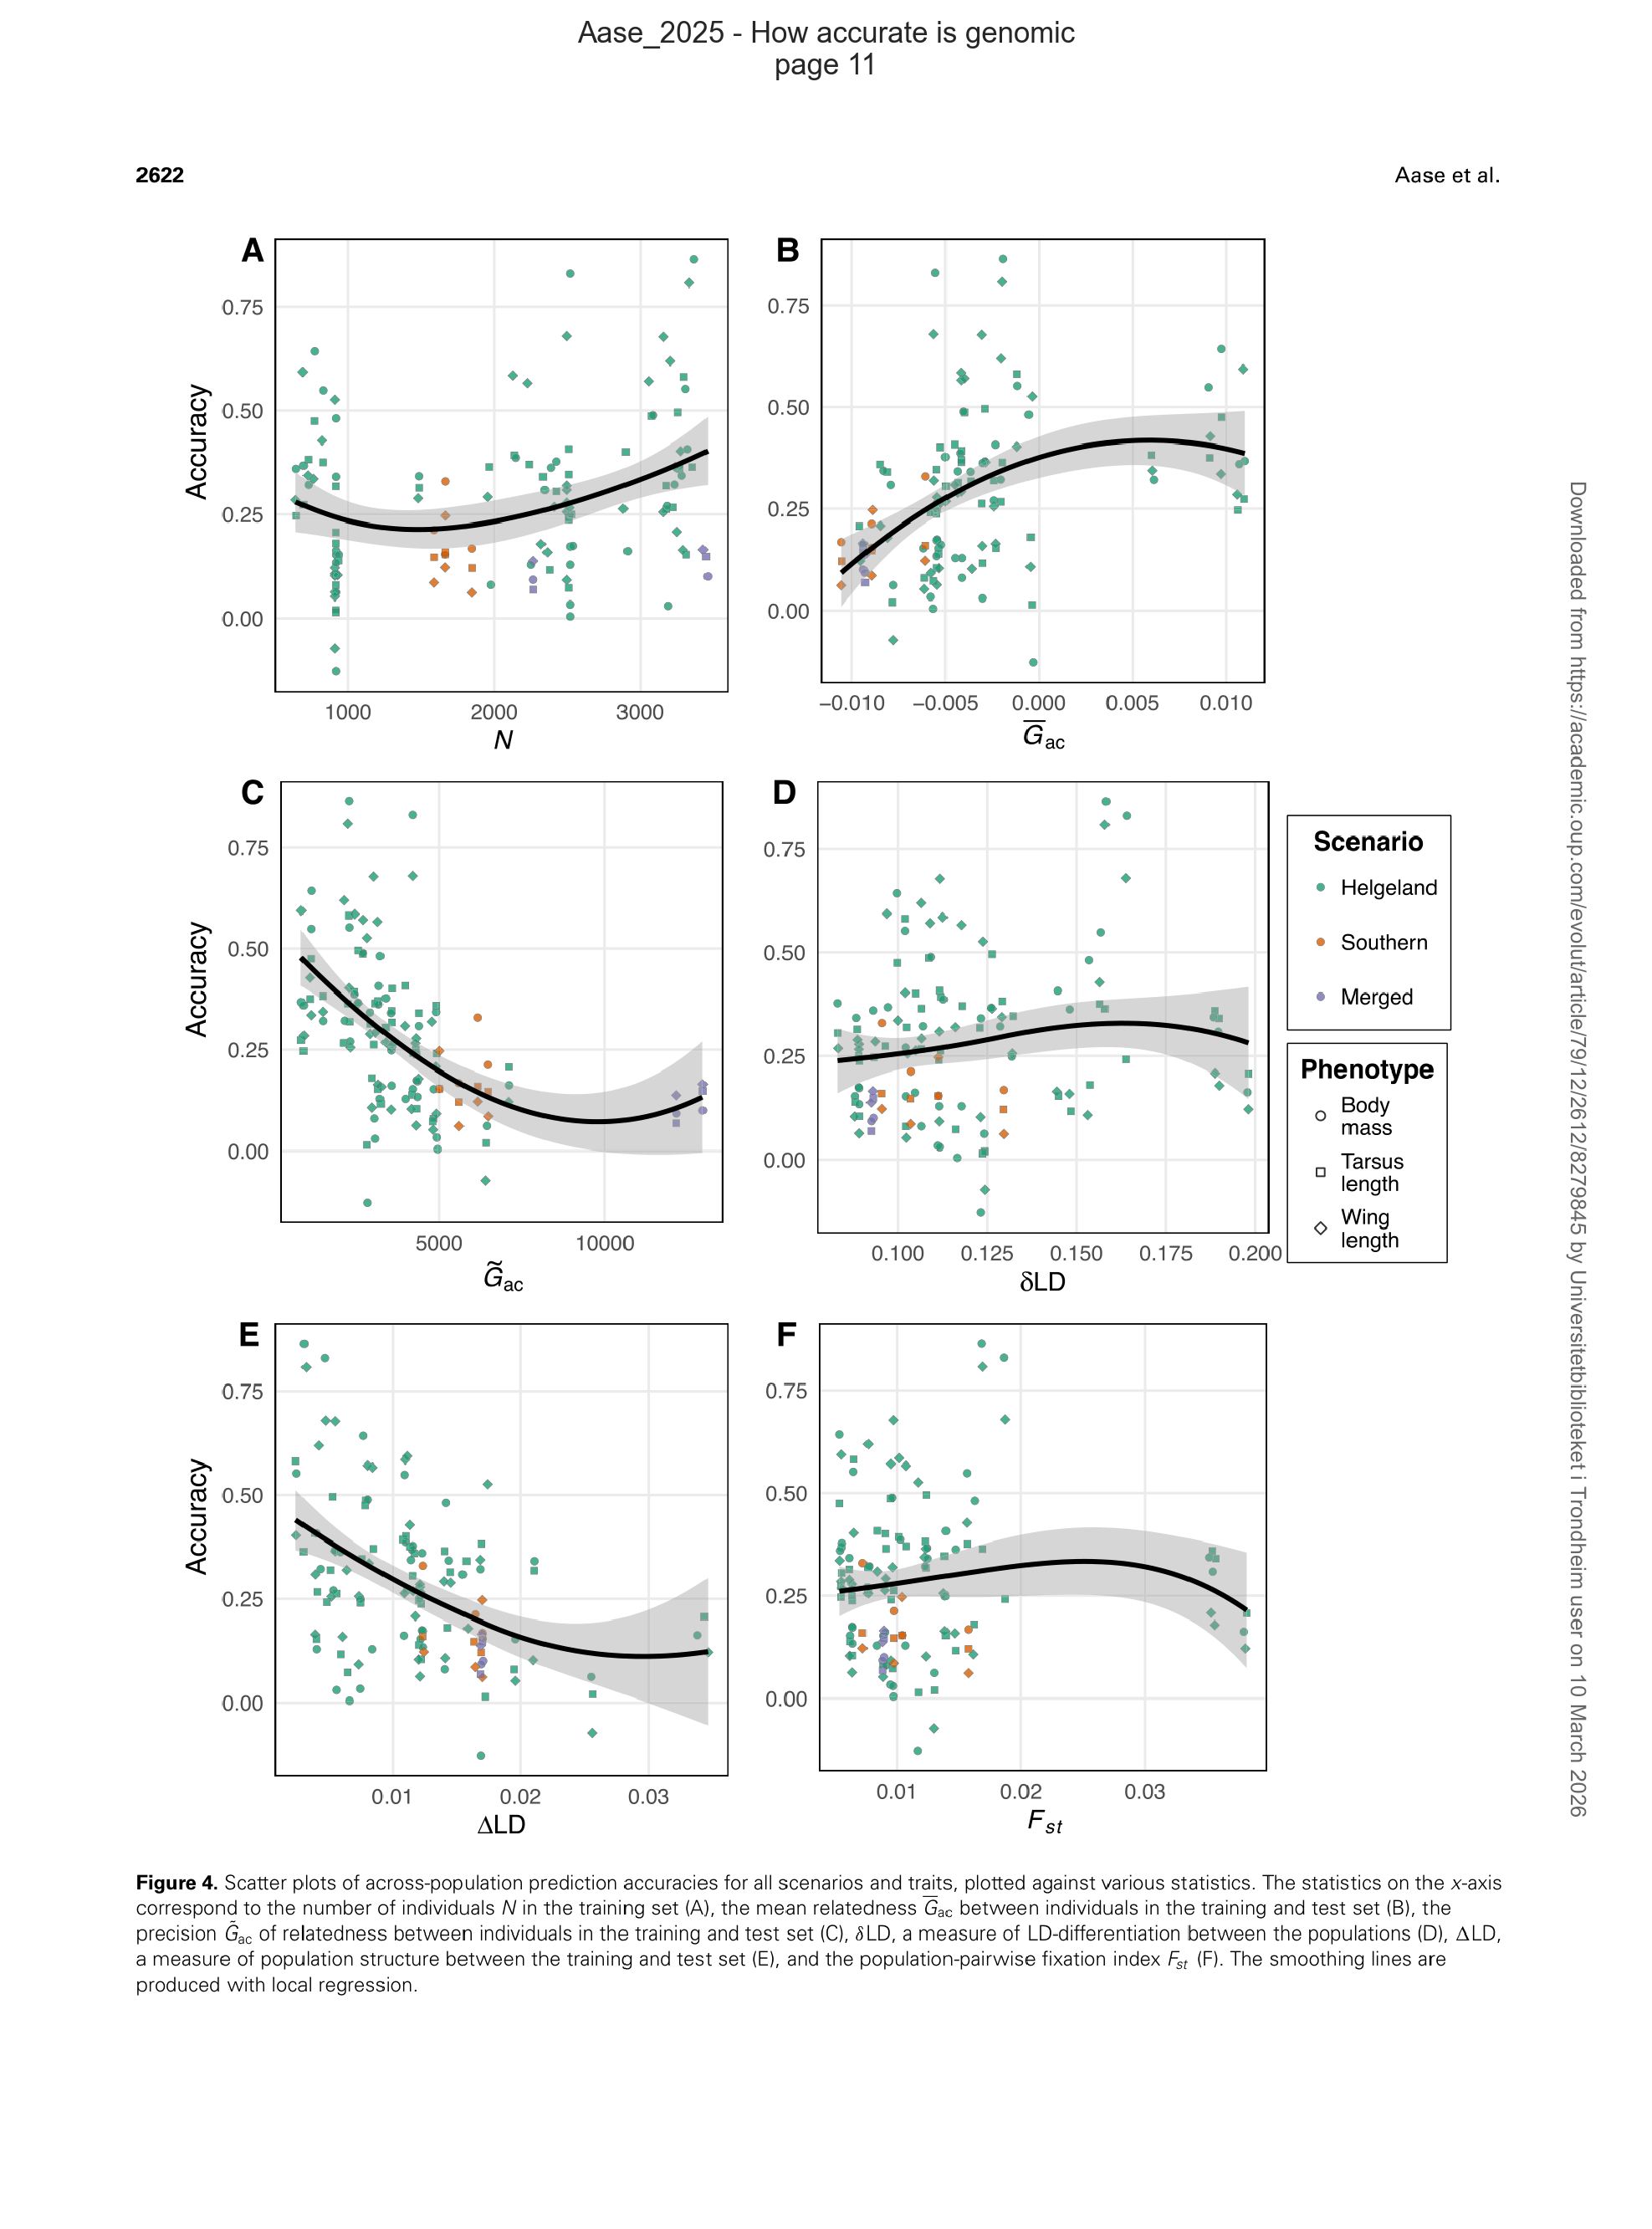

In [4]:
display_pdf(
    [PROJECT_ROOT / "papers" / "Aase_2025 - How accurate is genomic.pdf"],
    [10],
    zoom=3.2,
    col_width=8.0,
)

### Data shapley

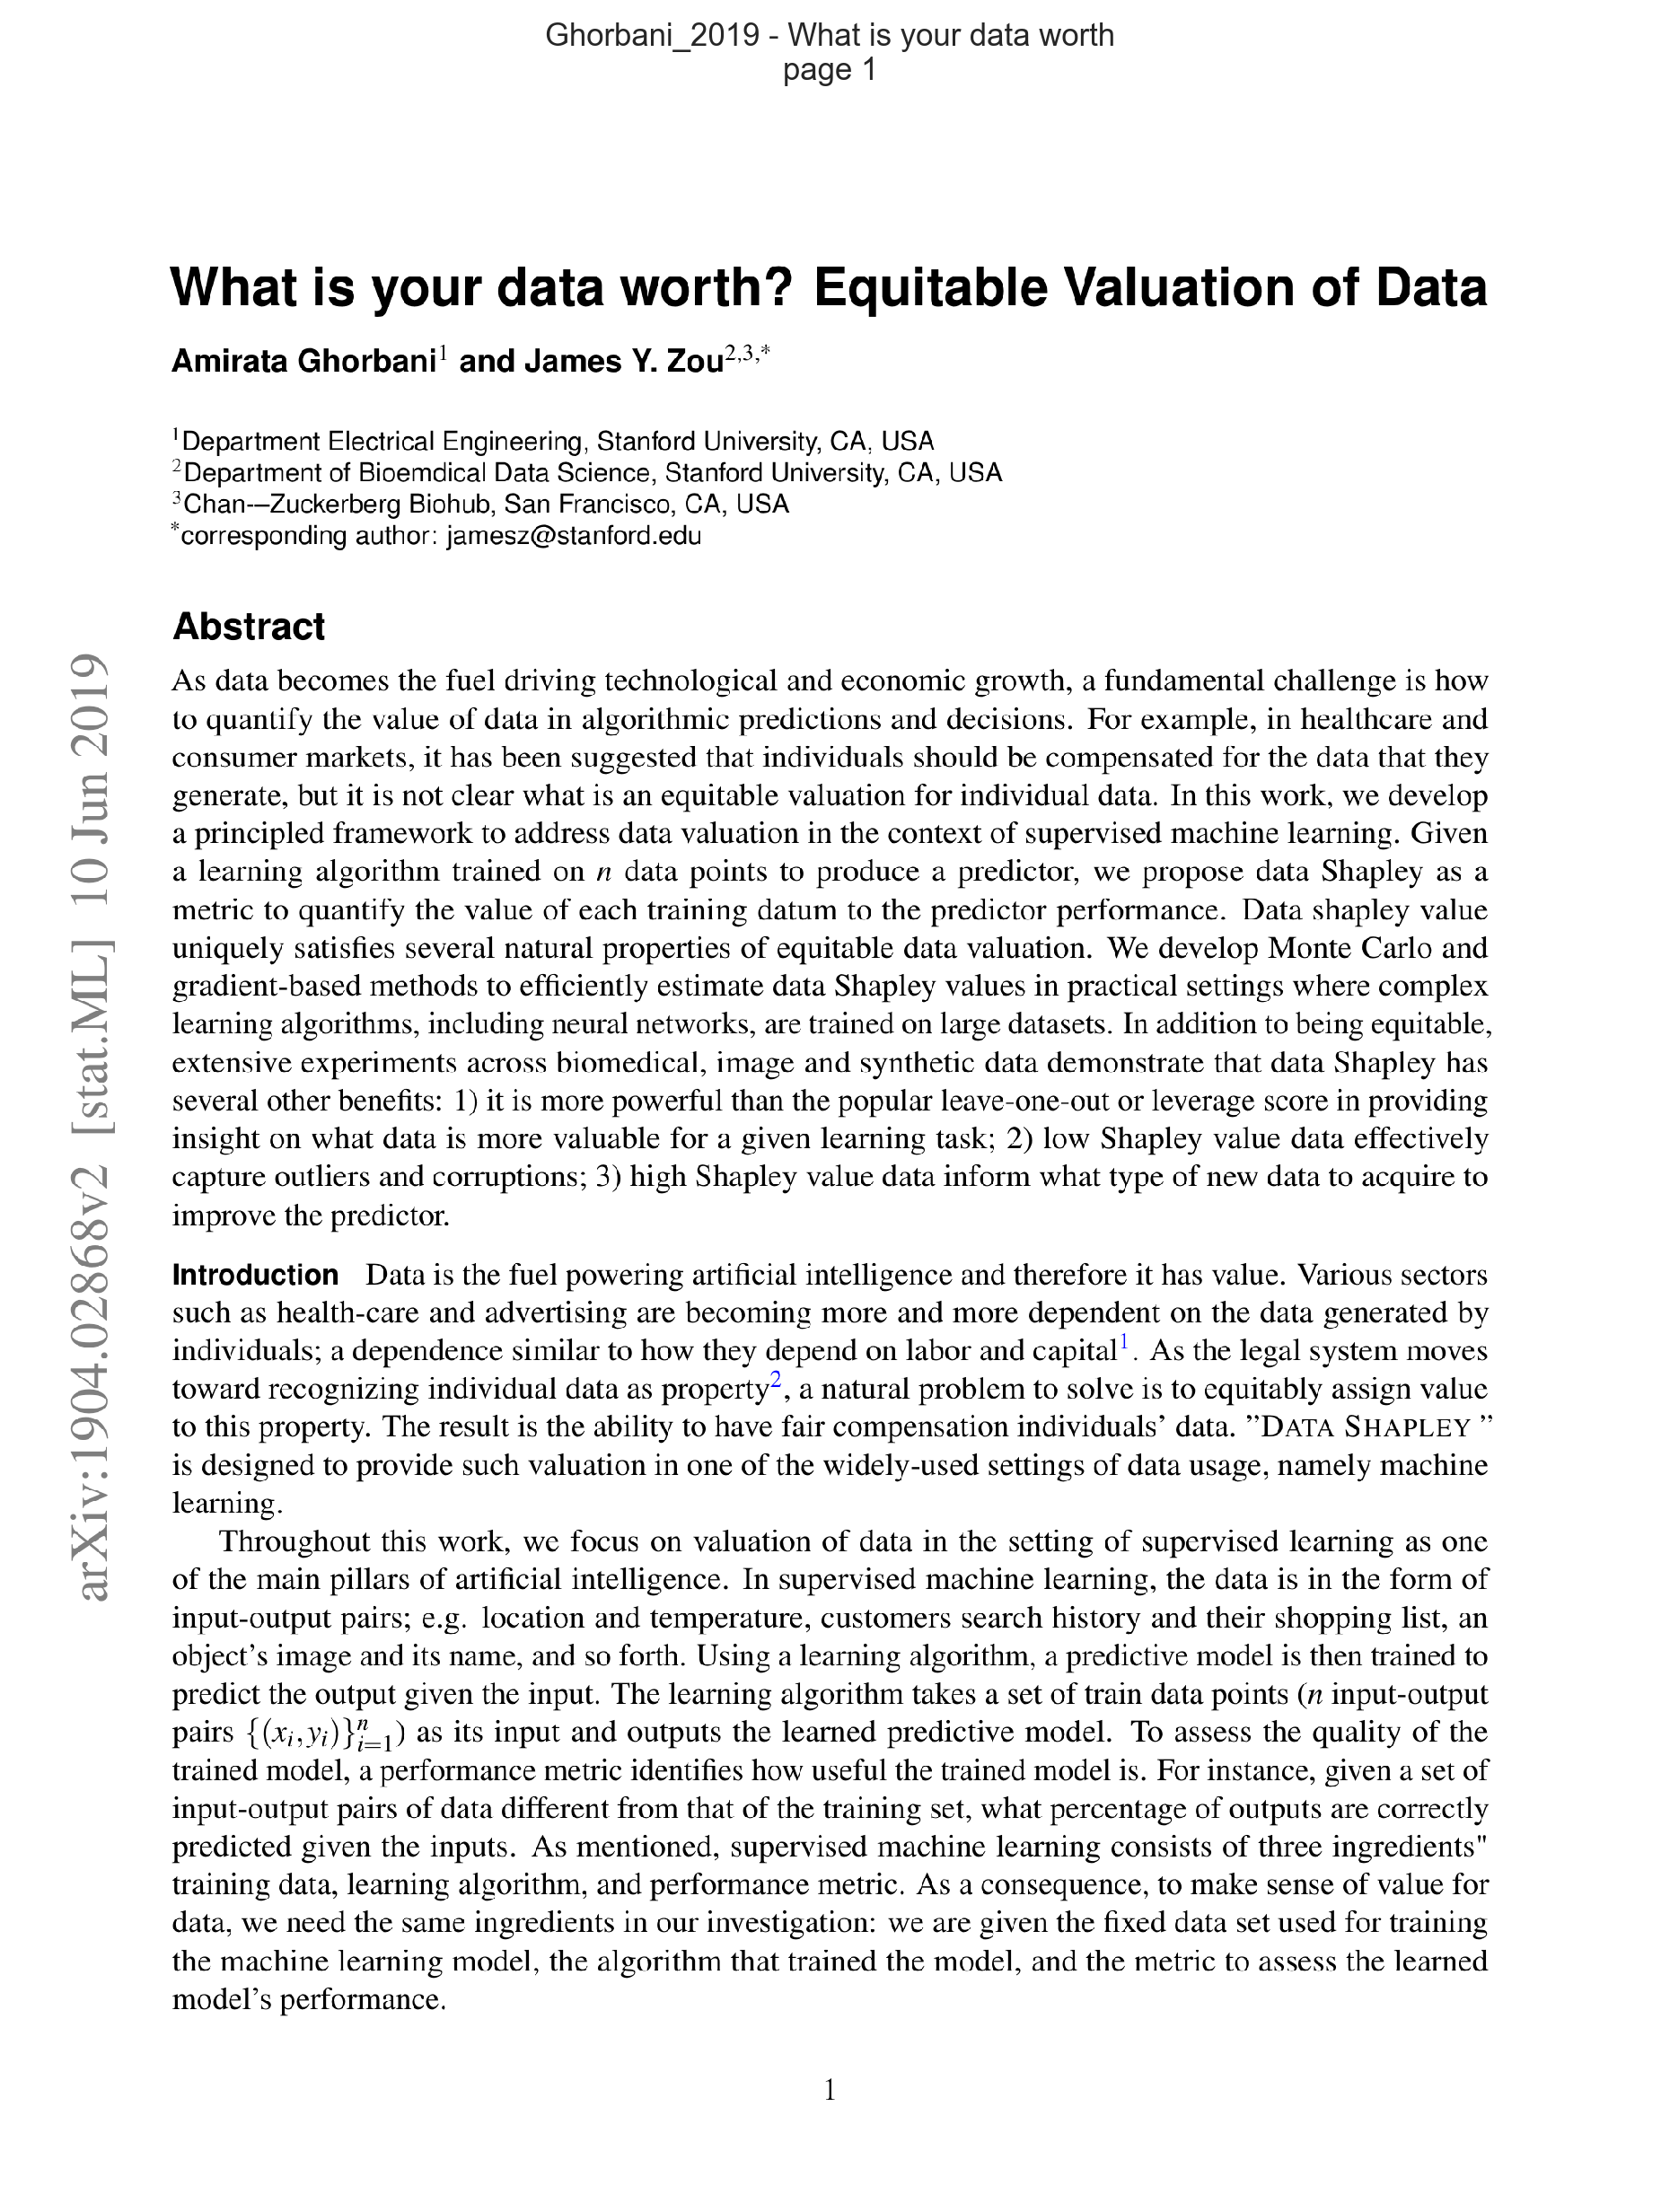

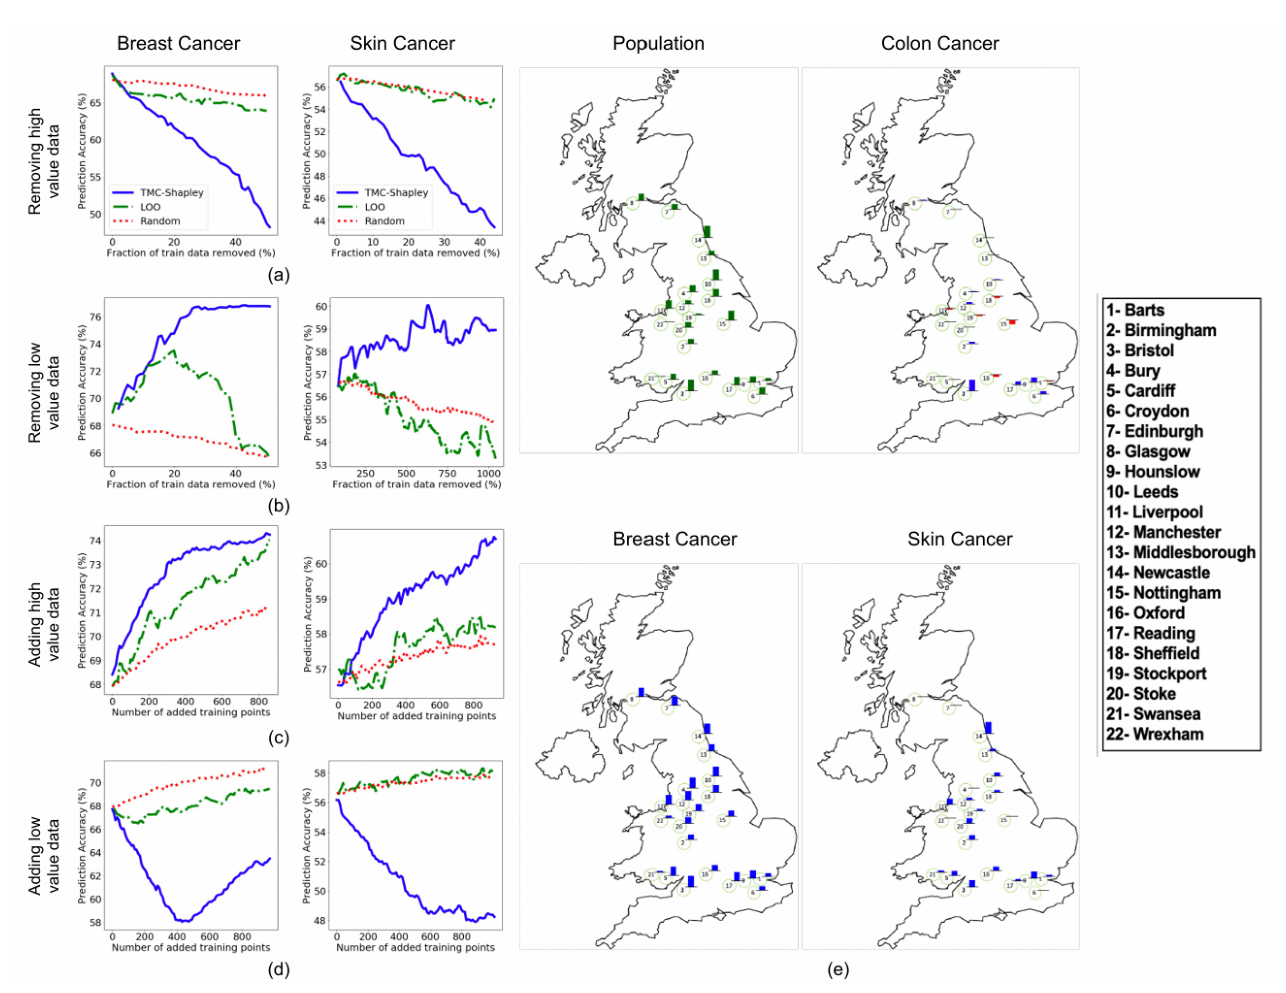

In [5]:
display_pdf(
    [
        PROJECT_ROOT / "papers" / "Ghorbani_2019 - What is your data worth.pdf"
    ],
    [0],
    zoom=3.2,
    col_width=7.5,
)
display_figure(PROJECT_ROOT / "papers" / "images" / "Ghorbani_2019 - Results.png")

### TracIn

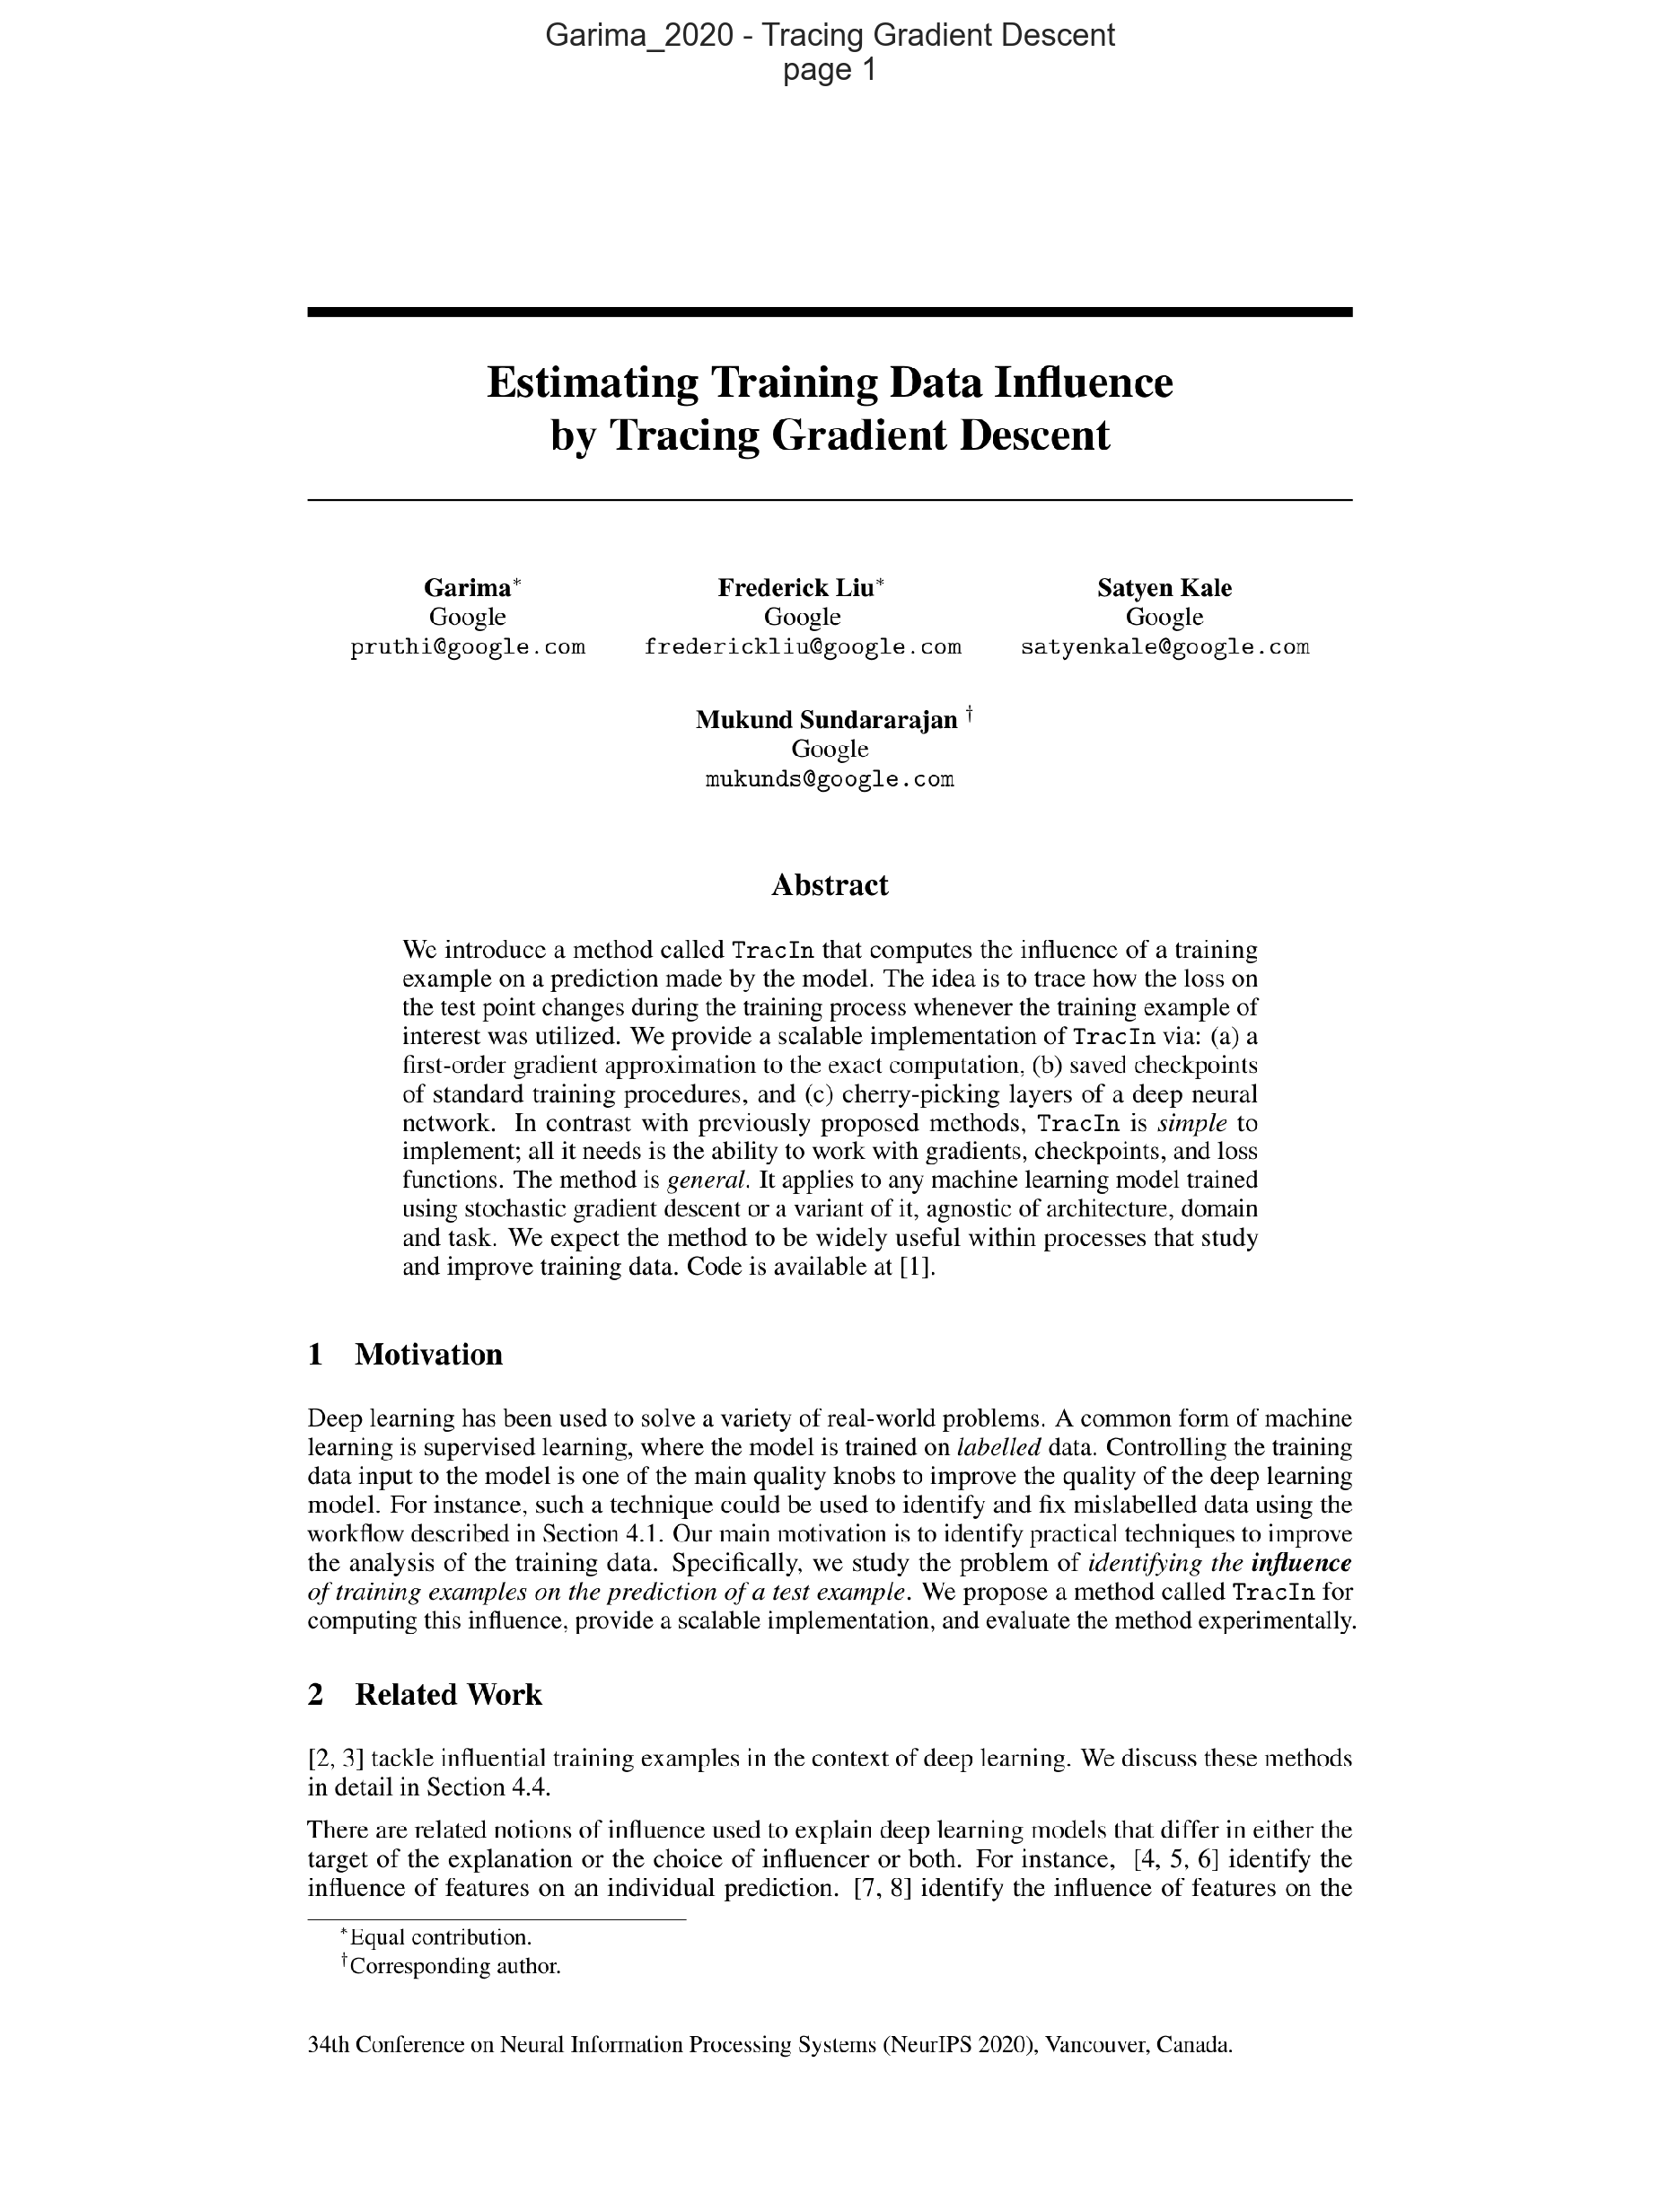

In [6]:
display_pdf([PROJECT_ROOT / "papers" / "Garima_2020 - Tracing Gradient Descent.pdf"], [0], zoom=3.2, col_width=7.5)

### Traditional methods

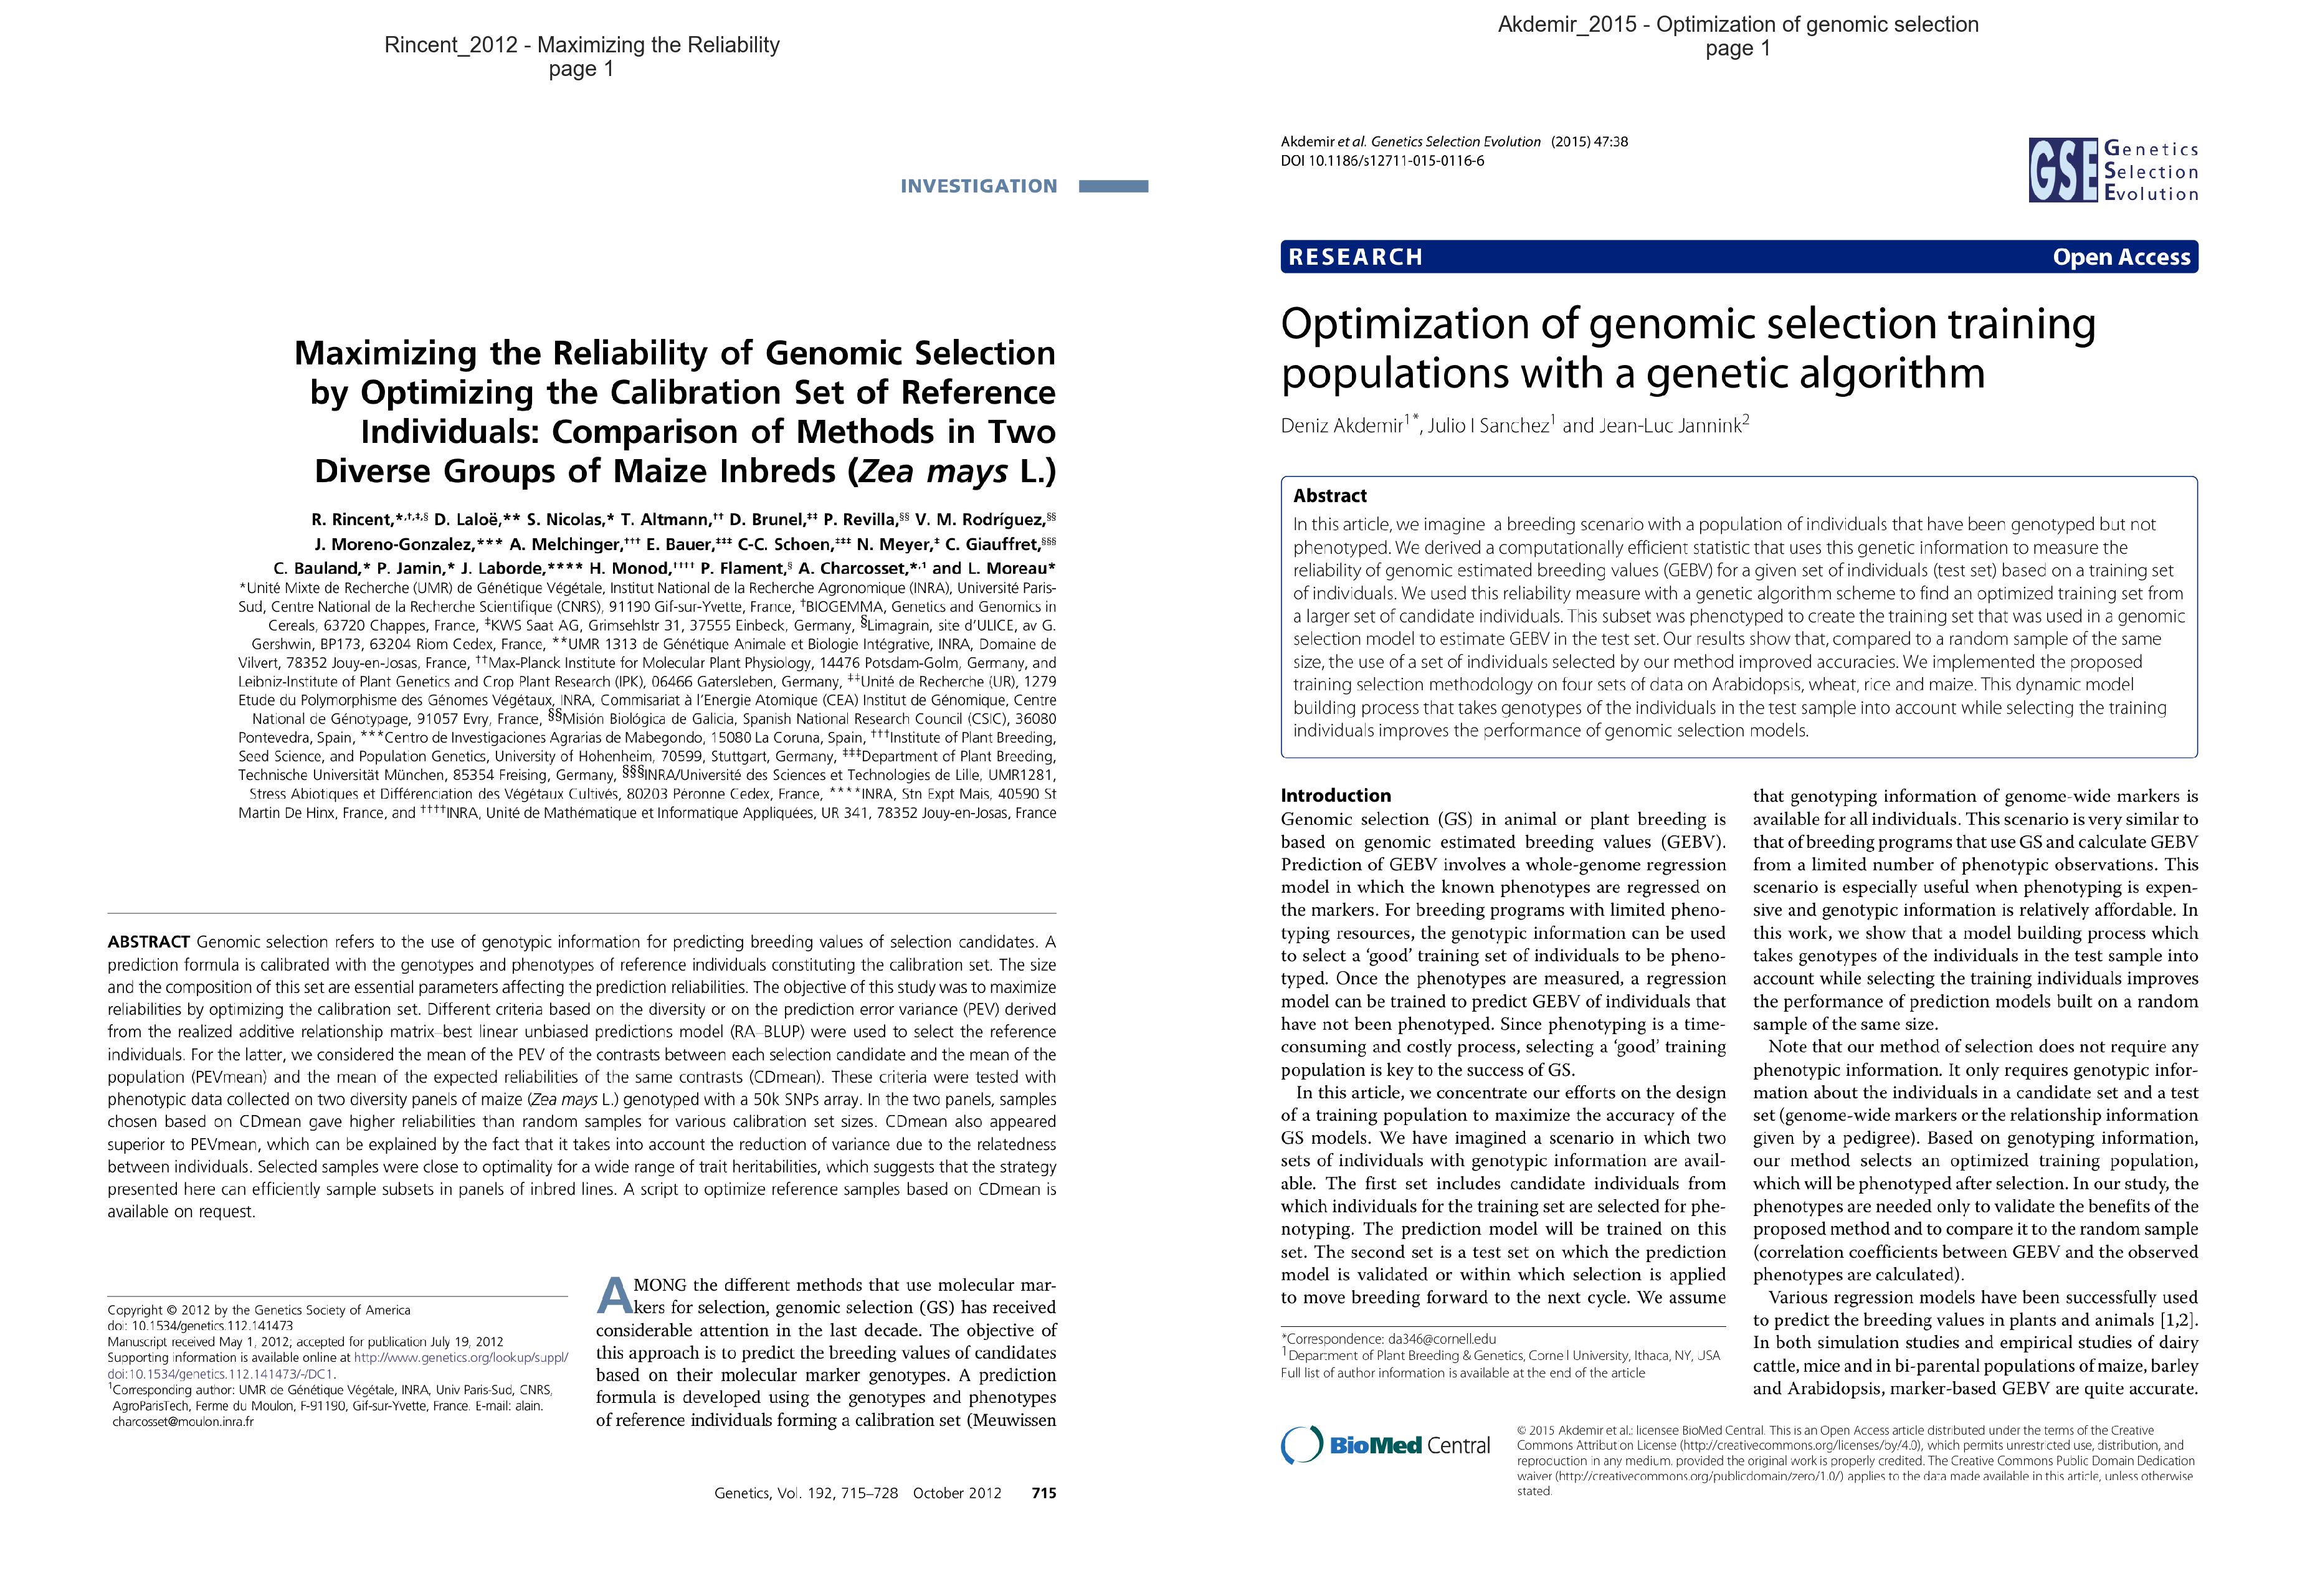

In [7]:
display_pdf([PROJECT_ROOT / "papers" / "Rincent_2012 - Maximizing the Reliability.pdf",
            PROJECT_ROOT / "papers" / "Akdemir_2015 - Optimization of genomic selection.pdf"],
            [0, 0], zoom=3.2, col_width=7.5)

#### Ideas

- PEV (Predicted error variance). Minimize expected PEV.
- CD (Coefficient of determination). Maximize expected CD.

## Models

- 2-step model with ridge regression
- shrinkage fixed

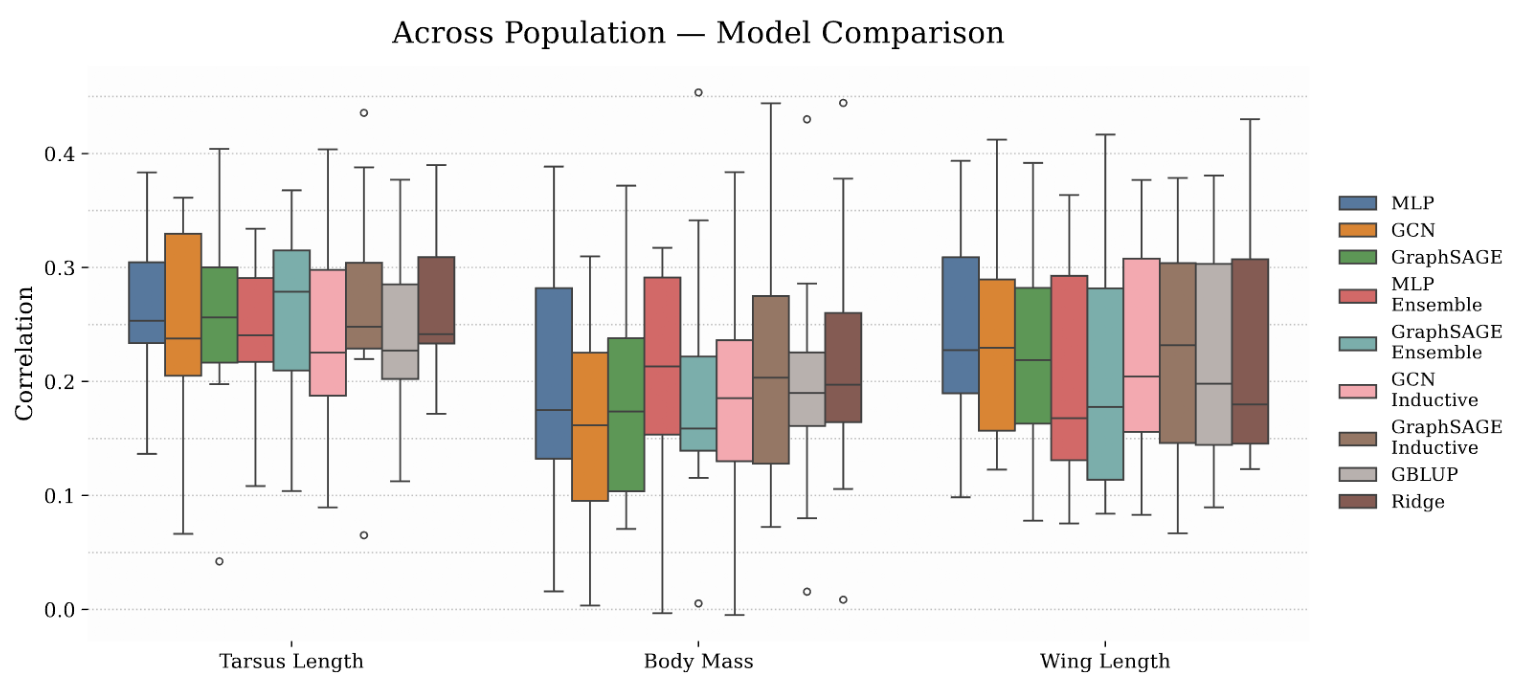

In [8]:
display_figure(PROJECT_ROOT / "figures" / "loio_single_panel.png")

## 3) Data shapley

`Ghorbani, Zou 2019 - What is your data worth? Equitable Valuation of Data`

### Shapley Value (data valuation)

- $D = \{x_i, y_i\}_{i=1}^{n}$: full training set (all data sources).
- $i$: the data source/individual we are valuing.
- $S \subseteq D \setminus \{i\}$: a subset that does not contain $i$.
- $V(S)$: predictive performance when training on subset $S$.
- $\phi_i$: Shapley value for source $i$ (its average contribution to performance).
- $C$: normalization constant so contributions are averaged over subset sizes.

$$
\phi_i = C \sum_{S \subseteq D \setminus \{i\}} \frac{V(S \cup \{i\}) - V(S)}{\binom{n-1}{|S|}}
$$

Interpretation: for each possible subset $S$, measure the marginal gain from adding $i$ and average those gains fairly over all subset sizes.

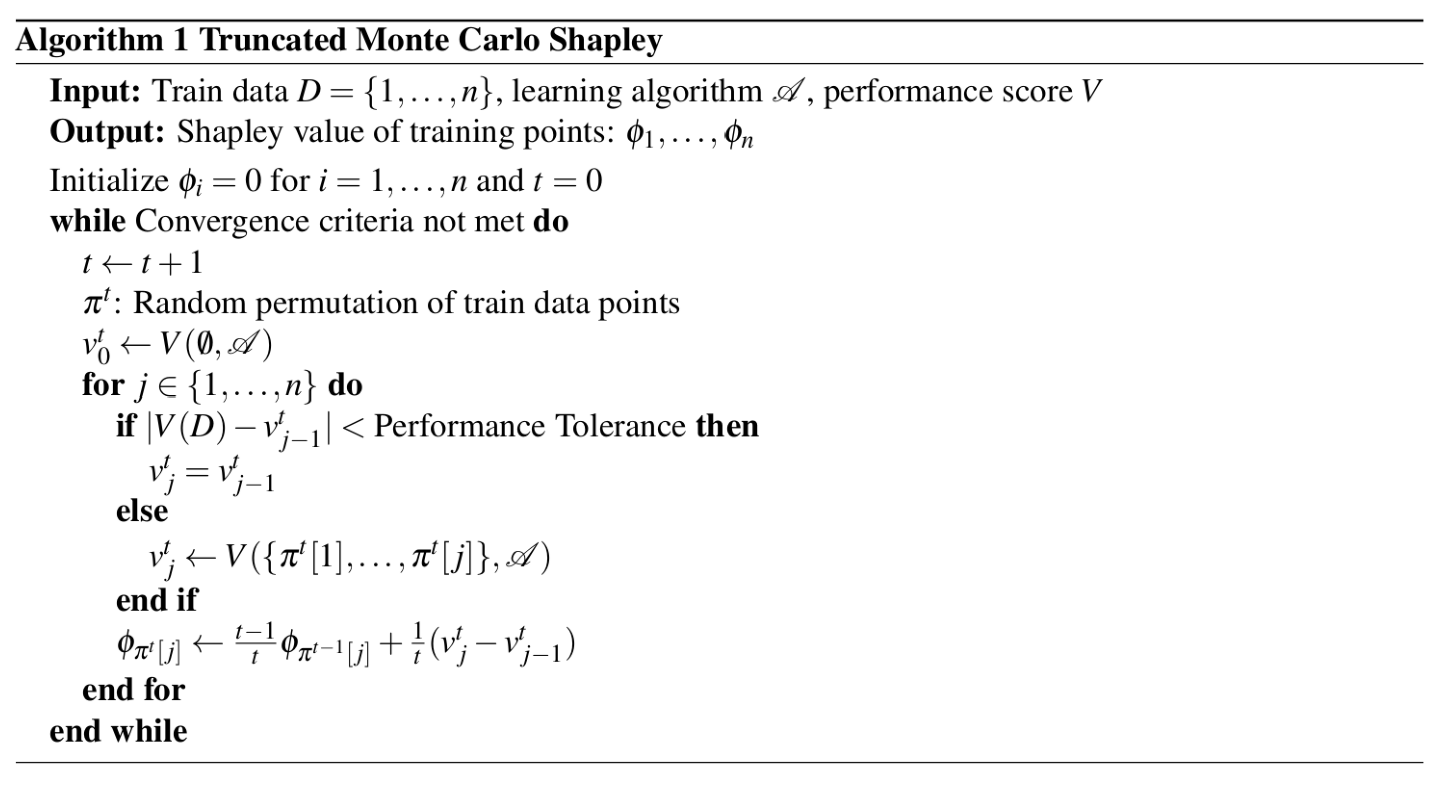

In [9]:
display_figure(PROJECT_ROOT / "papers" / "images" / "shapley_alg.png")

Will be super slow with 3'000 - 6'000 training individuals. Idea: Do it island-wise.

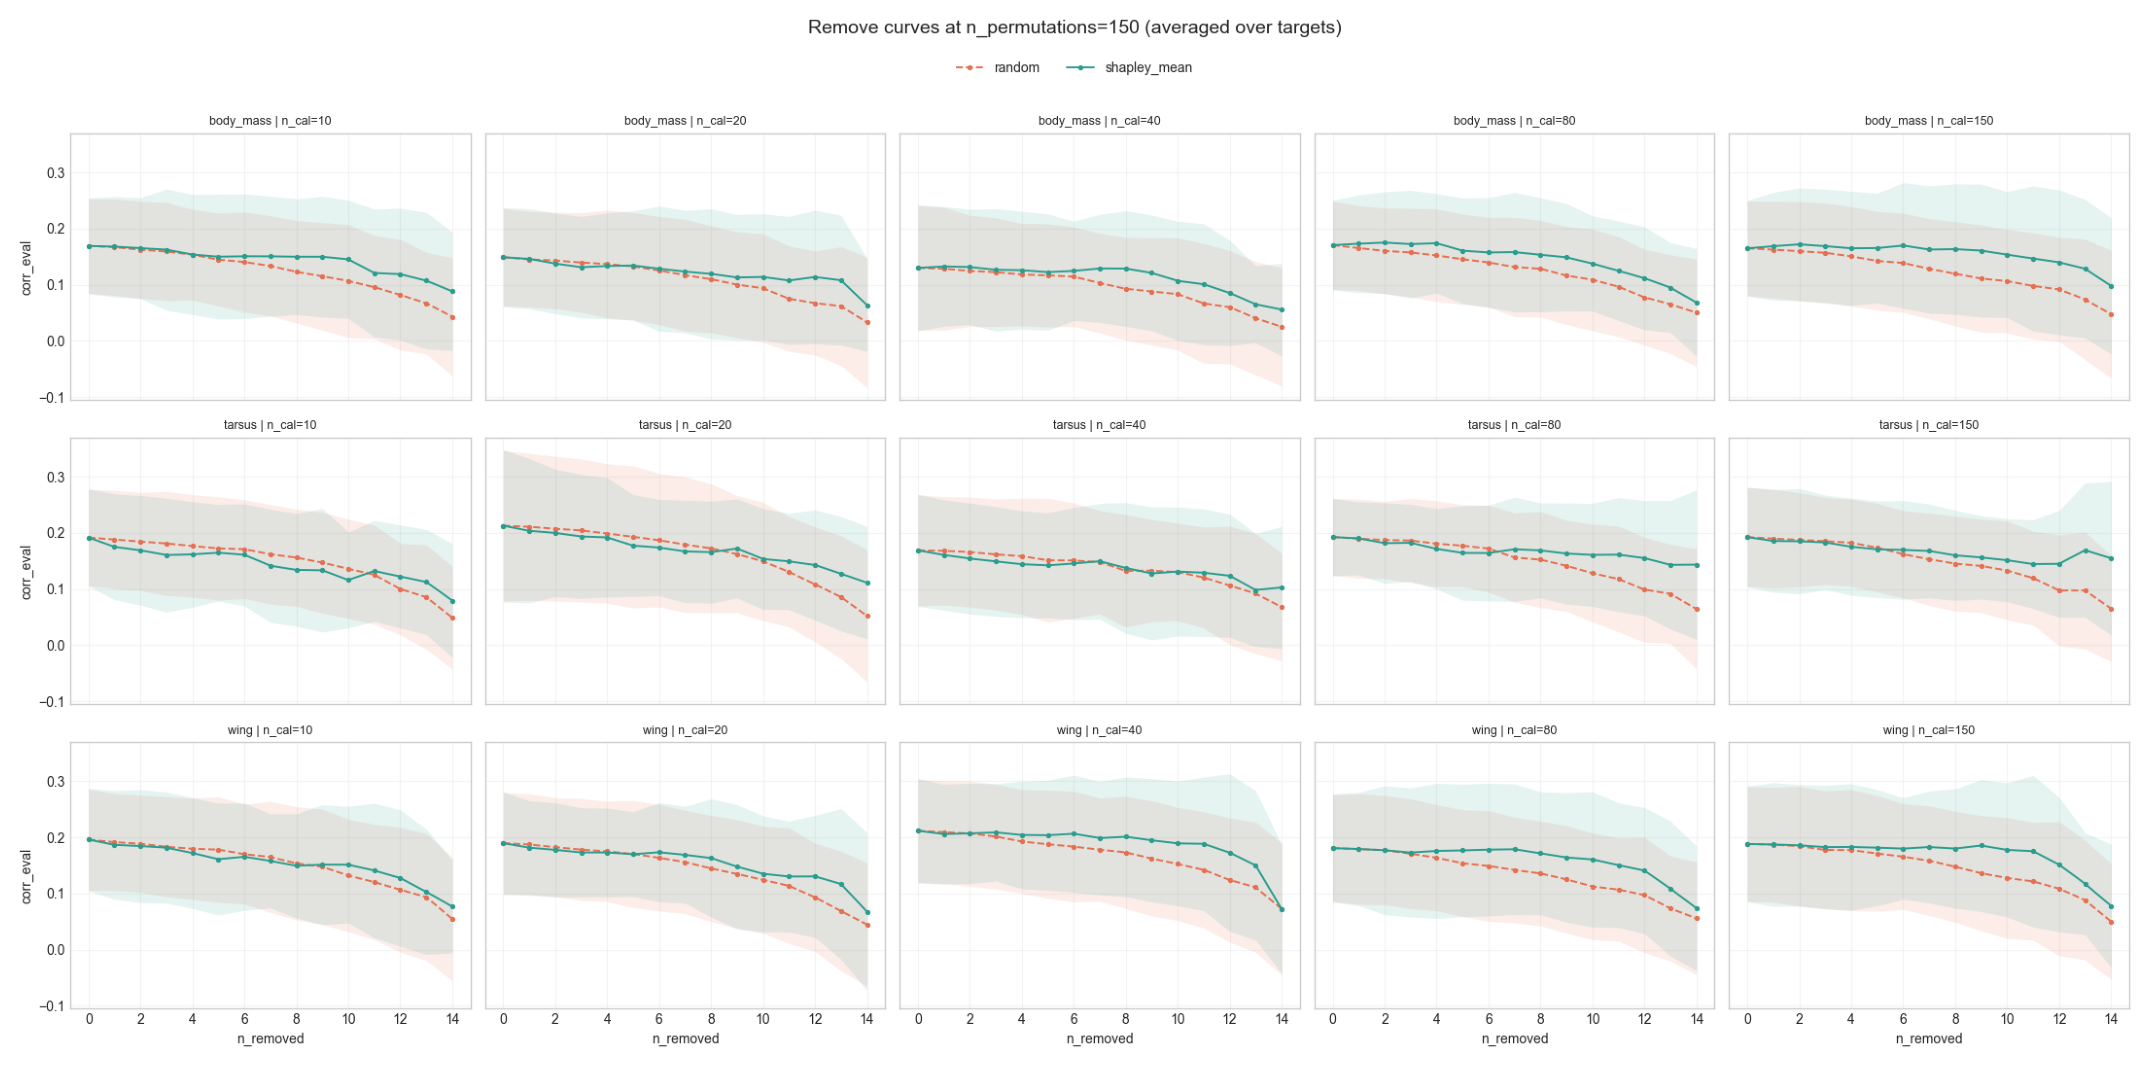

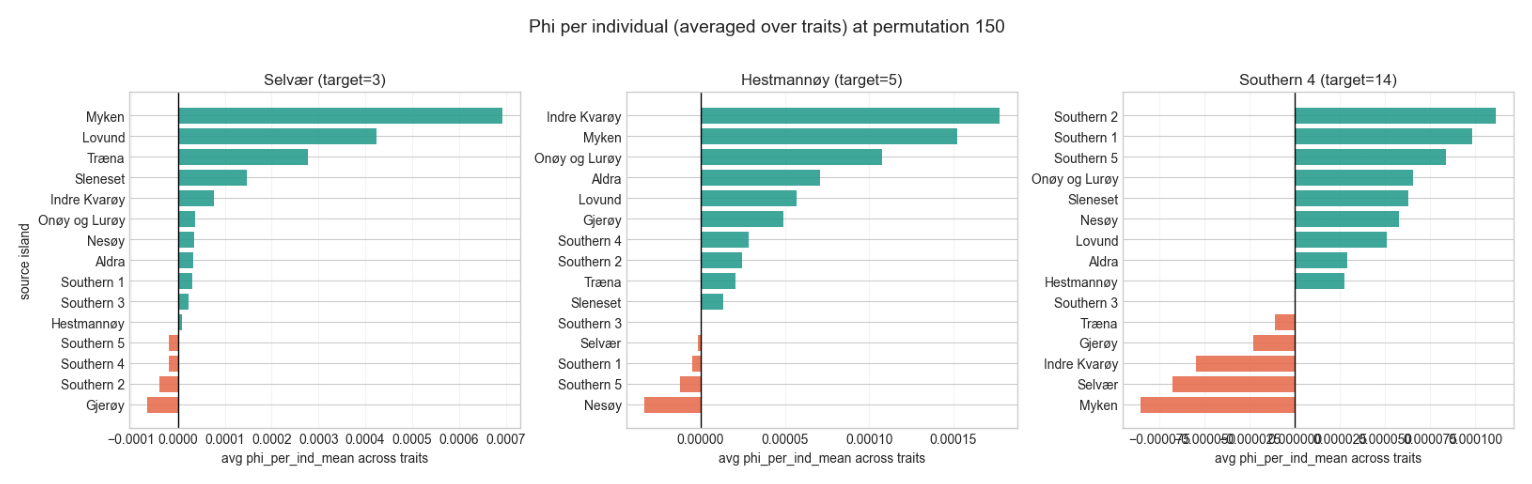

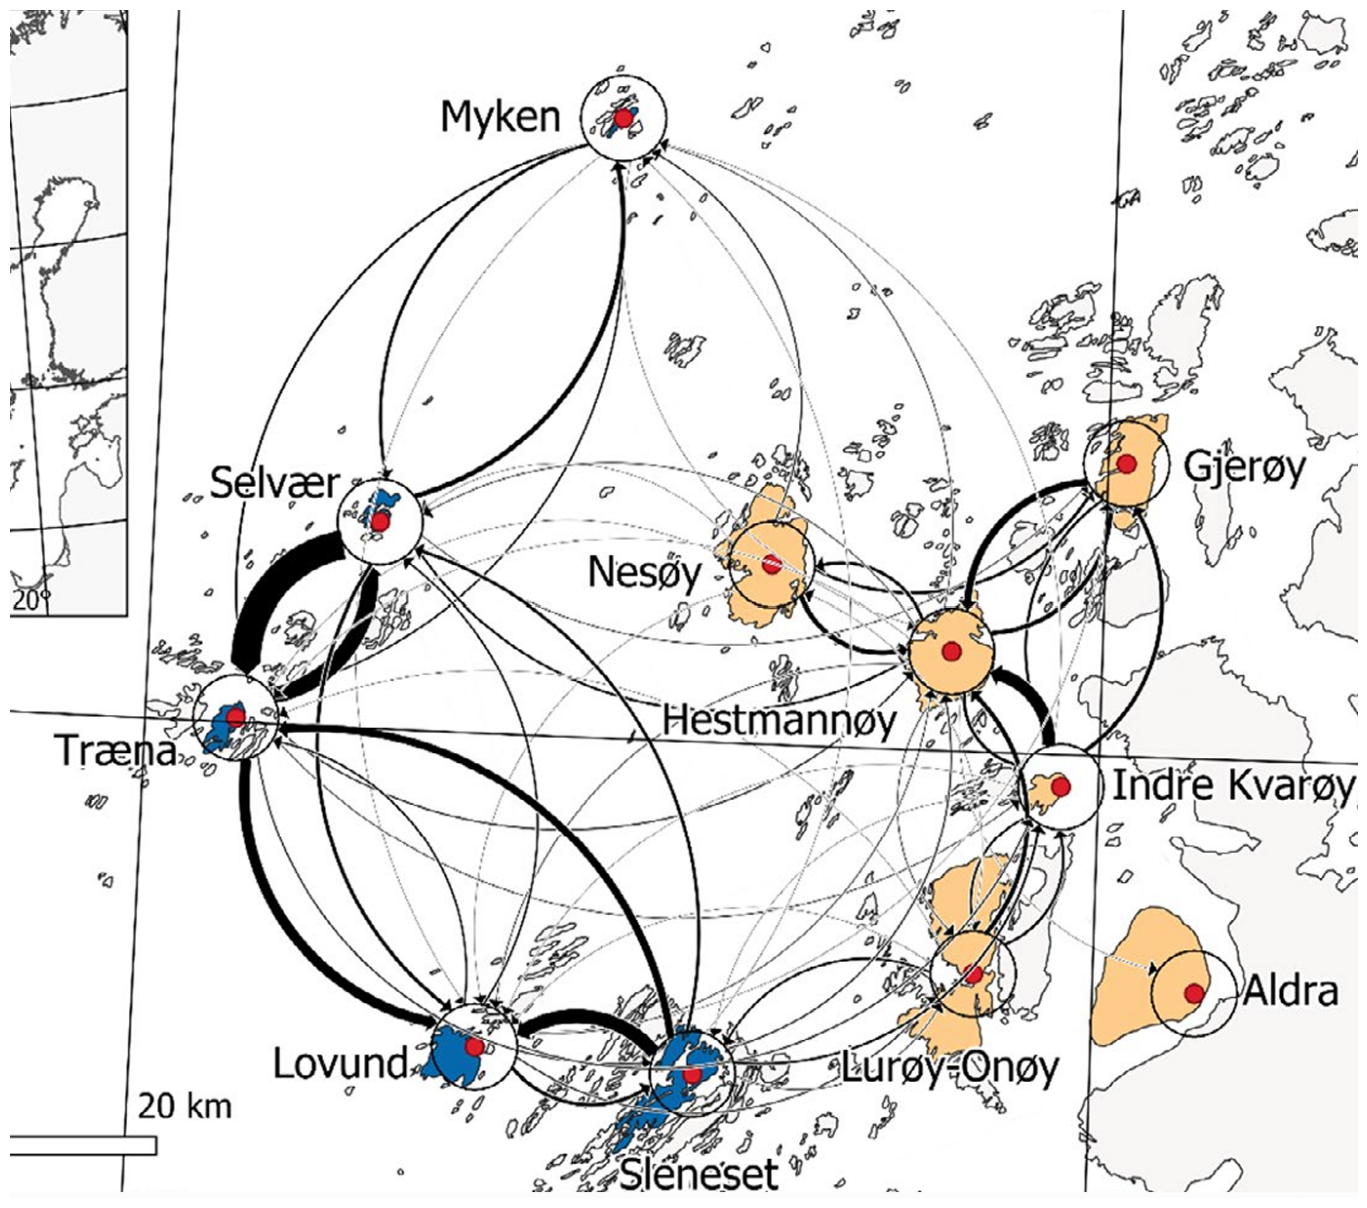

In [10]:
display_figure(PROJECT_ROOT / "figures" / "shap_removed_vs_accuracy.png")
display_figure(PROJECT_ROOT / "figures" / "shap_shapvals.png")
display_figure(PROJECT_ROOT / "figures" / "islands.png")

## 4) TracIn

`Pruthi et al. 2020 - Estimating Training Data Influence by Tracing Gradient Descent`

### Main idea

- Goal: estimate how much each training point influences a test prediction.
- Influence is approximated by tracing training checkpoints and accumulating gradient similarity.
- If a train point gradient aligns with the test gradient, it is helpful; opposite direction suggests harmful influence.


A common TracIn score form is:

$$
\mathrm{TracIn}(z_{train}, z_{test}) = \sum_t \eta_t \, \nabla_\theta \ell(z_{train}, \theta_t)^\top \nabla_\theta \ell(z_{test}, \theta_t)
$$

where $t$ indexes training checkpoints and $\eta_t$ is the step size at checkpoint $t$.

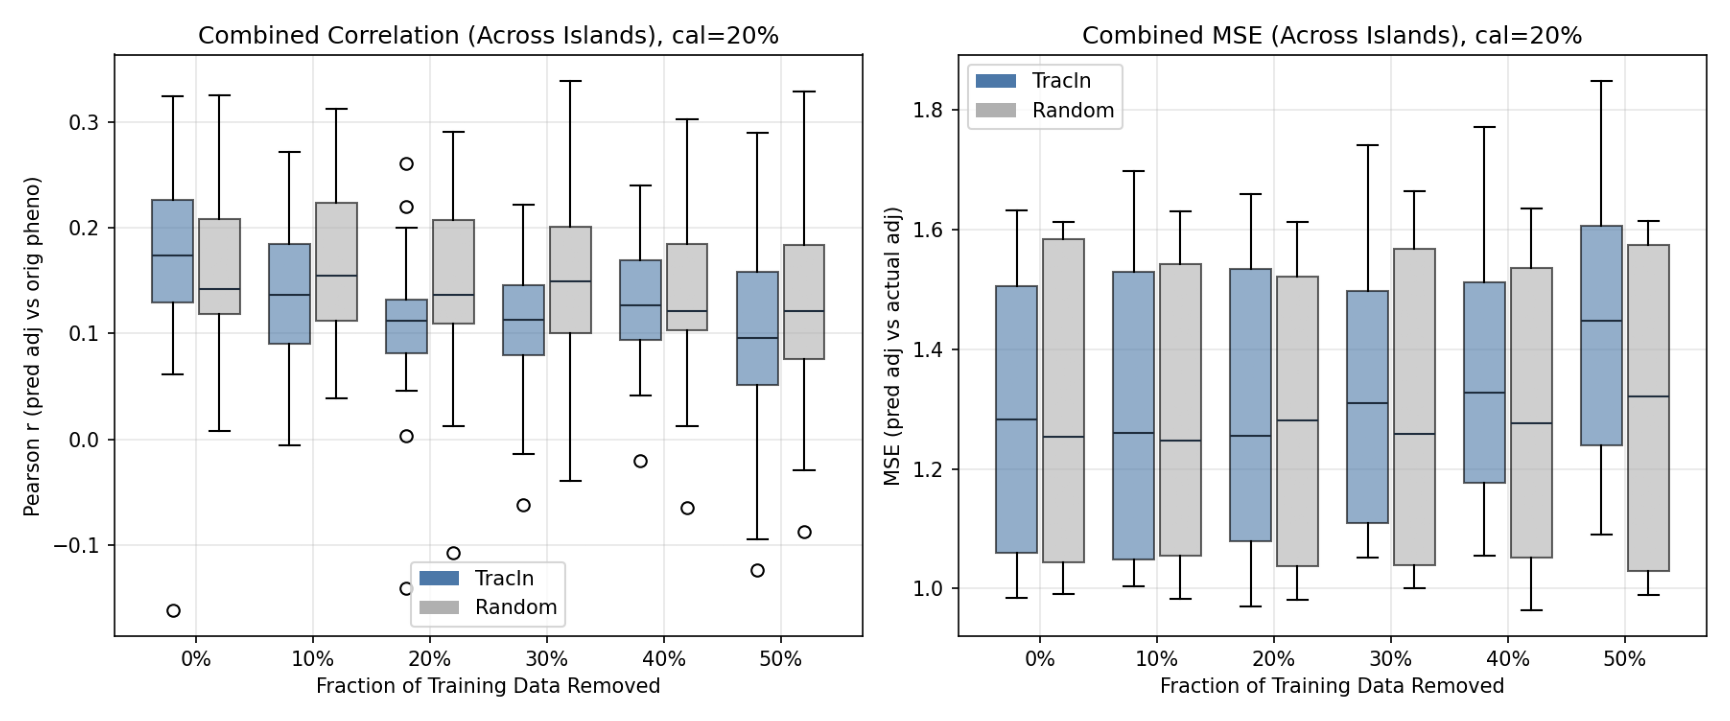

In [20]:
display_figure(PROJECT_ROOT / "outputs" / "tracin_multi" / "combined_removal_curves_cal_20.png")

Tracin score distribution not clear, as opposed to Data Shapley.

## 5) Simpler methods

Methods that do not require "cheat data". They use genotypes (SNP-derived structure) rather than phenotypes for ranking and subset selection.

### 5.1) Prediction error variance (PEVmean) with GA

- Start from prediction error variance of target breeding values:

$$
\mathrm{PEV}_T(S) = \mathrm{Var}\!\left(u_T - \hat{u}_T \mid S\right)
$$

- Here $S$ is the selected training subset (size $k$), and $T$ is the target set we want to predict well.
- Under ridge/GBLUP mixed-model assumptions, this covariance is approximated by

$$
\mathrm{PEV}_T(S) = G_{TT} - G_{TS}\left(G_{SS} + \lambda I\right)^{-1}G_{ST}, \qquad \lambda = \sigma_e^2/\sigma_u^2
$$

- Subscript meaning (important):
  - $G_{SS}$: rows/cols both from selected training subset $S$ (within-training block).
  - $G_{TT}$: rows/cols both from target set $T$ (within-target block).
  - $G_{TS}$: rows from $T$, cols from $S$ (target-to-training relationships).
  - $G_{ST}$: transpose block, rows from $S$, cols from $T$.

- Scalar objective (PEVmean) is the average target uncertainty:

$$
J(S) = \frac{1}{|T|}\operatorname{tr}\!\left(\mathrm{PEV}_T(S)\right), \quad |S|=k
$$

- Intuition: lower $J(S)$ means more reliable predictions for target individuals.
- Exact subset search is infeasible, so we minimize $J(S)$ approximately with a genetic algorithm (selection/crossover/mutation).

### 5.2) Average GRM ($\bar{G}$) + top-$k$

- Intuition: rank candidates by genetic relatedness to the target island, then pick the closest.
- Let $T$ be target individuals and $c$ one candidate from source pool.
- Candidate score is mean relationship to target set:

$$
s(c) = \frac{1}{|T|}\sum_{t \in T} G_{t,c}
$$

where $G$ is the genomic relationship matrix.
- Rank candidates by $s(c)$ in descending order and choose top-$k$.

### 5.3) PC distance + top-$k$

- Fit PCA on candidate training genotypes and keep first $m$ components.
- Let $z_i \in \mathbb{R}^m$ be PC scores for individual $i$.
- Compute target centroid in PC space:

$$
\mu_T = \frac{1}{|T|}\sum_{t \in T} z_t
$$

- Score each candidate by Euclidean distance to this centroid:

$$
d(c) = \|z_c - \mu_T\|_2 = \sqrt{\sum_{j=1}^{m}(z_{c,j}-\mu_{T,j})^2}
$$

- Select top-$k$ candidates with smallest $d(c)$ (nearest neighbors to target island in reduced genetic space).

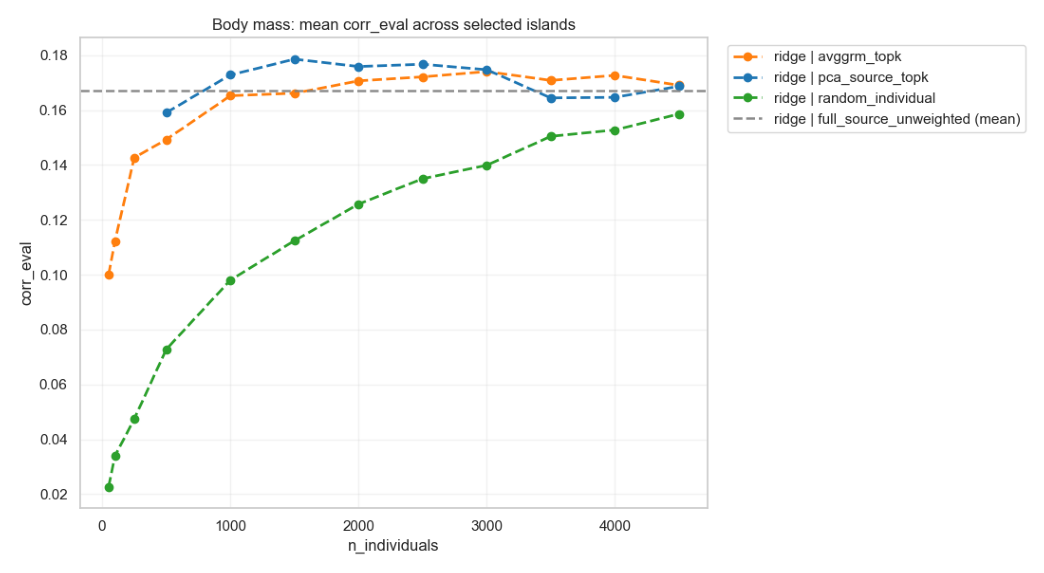

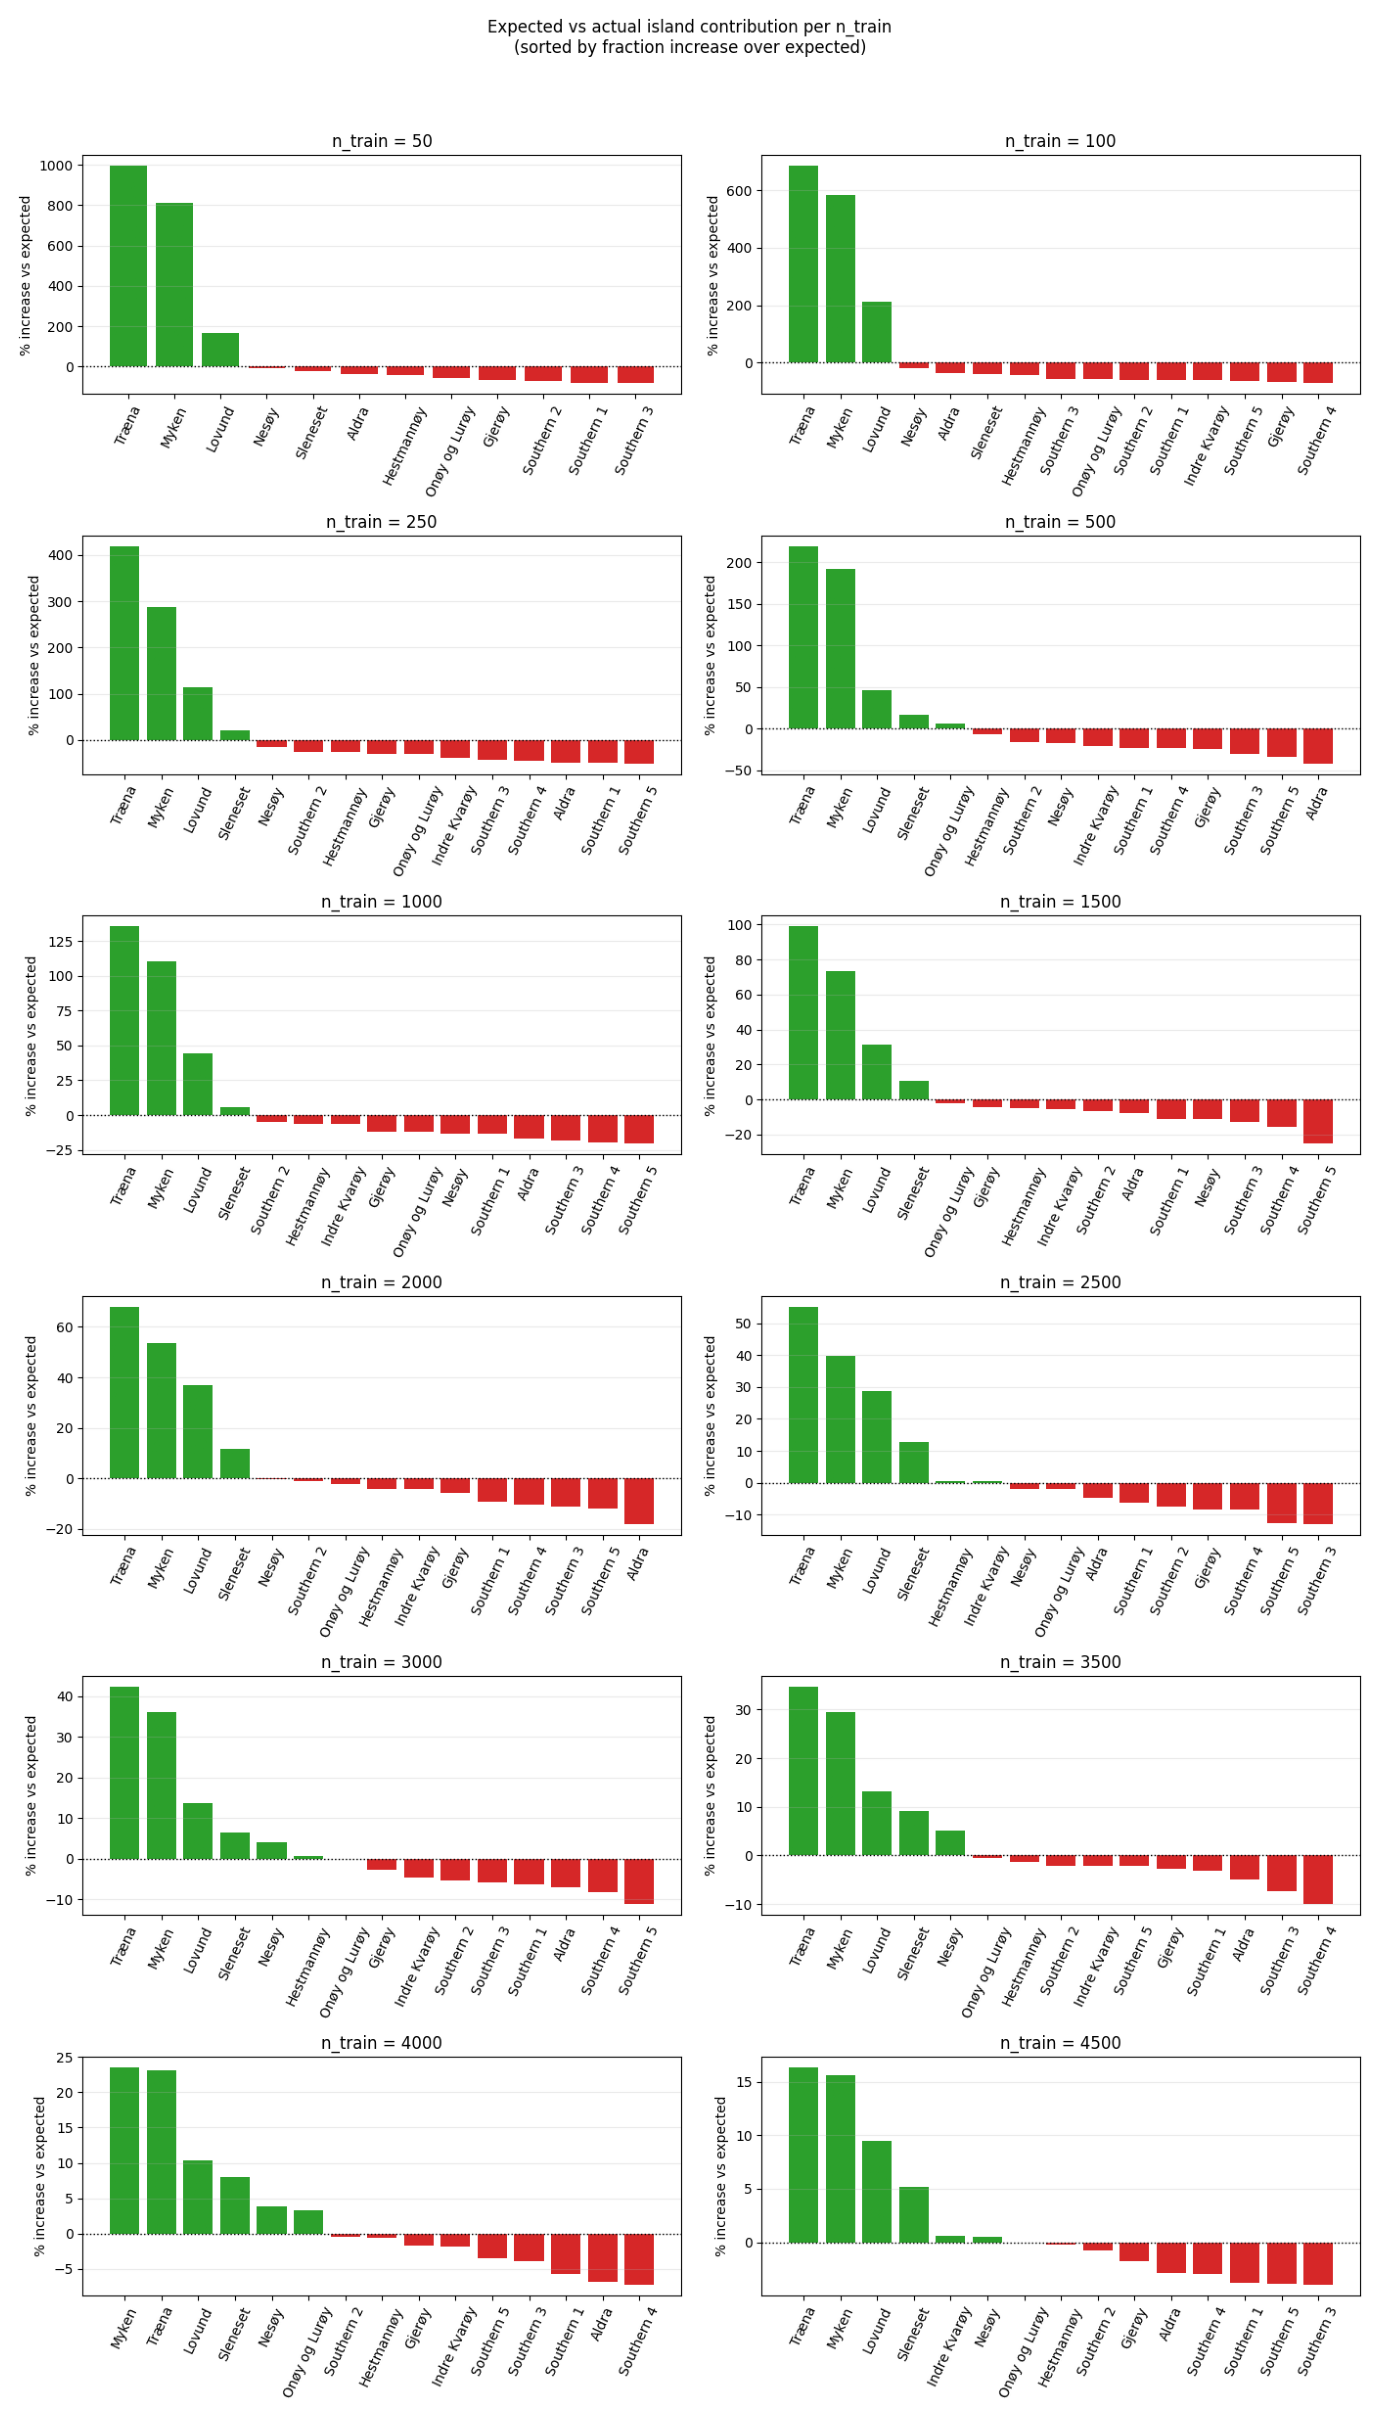

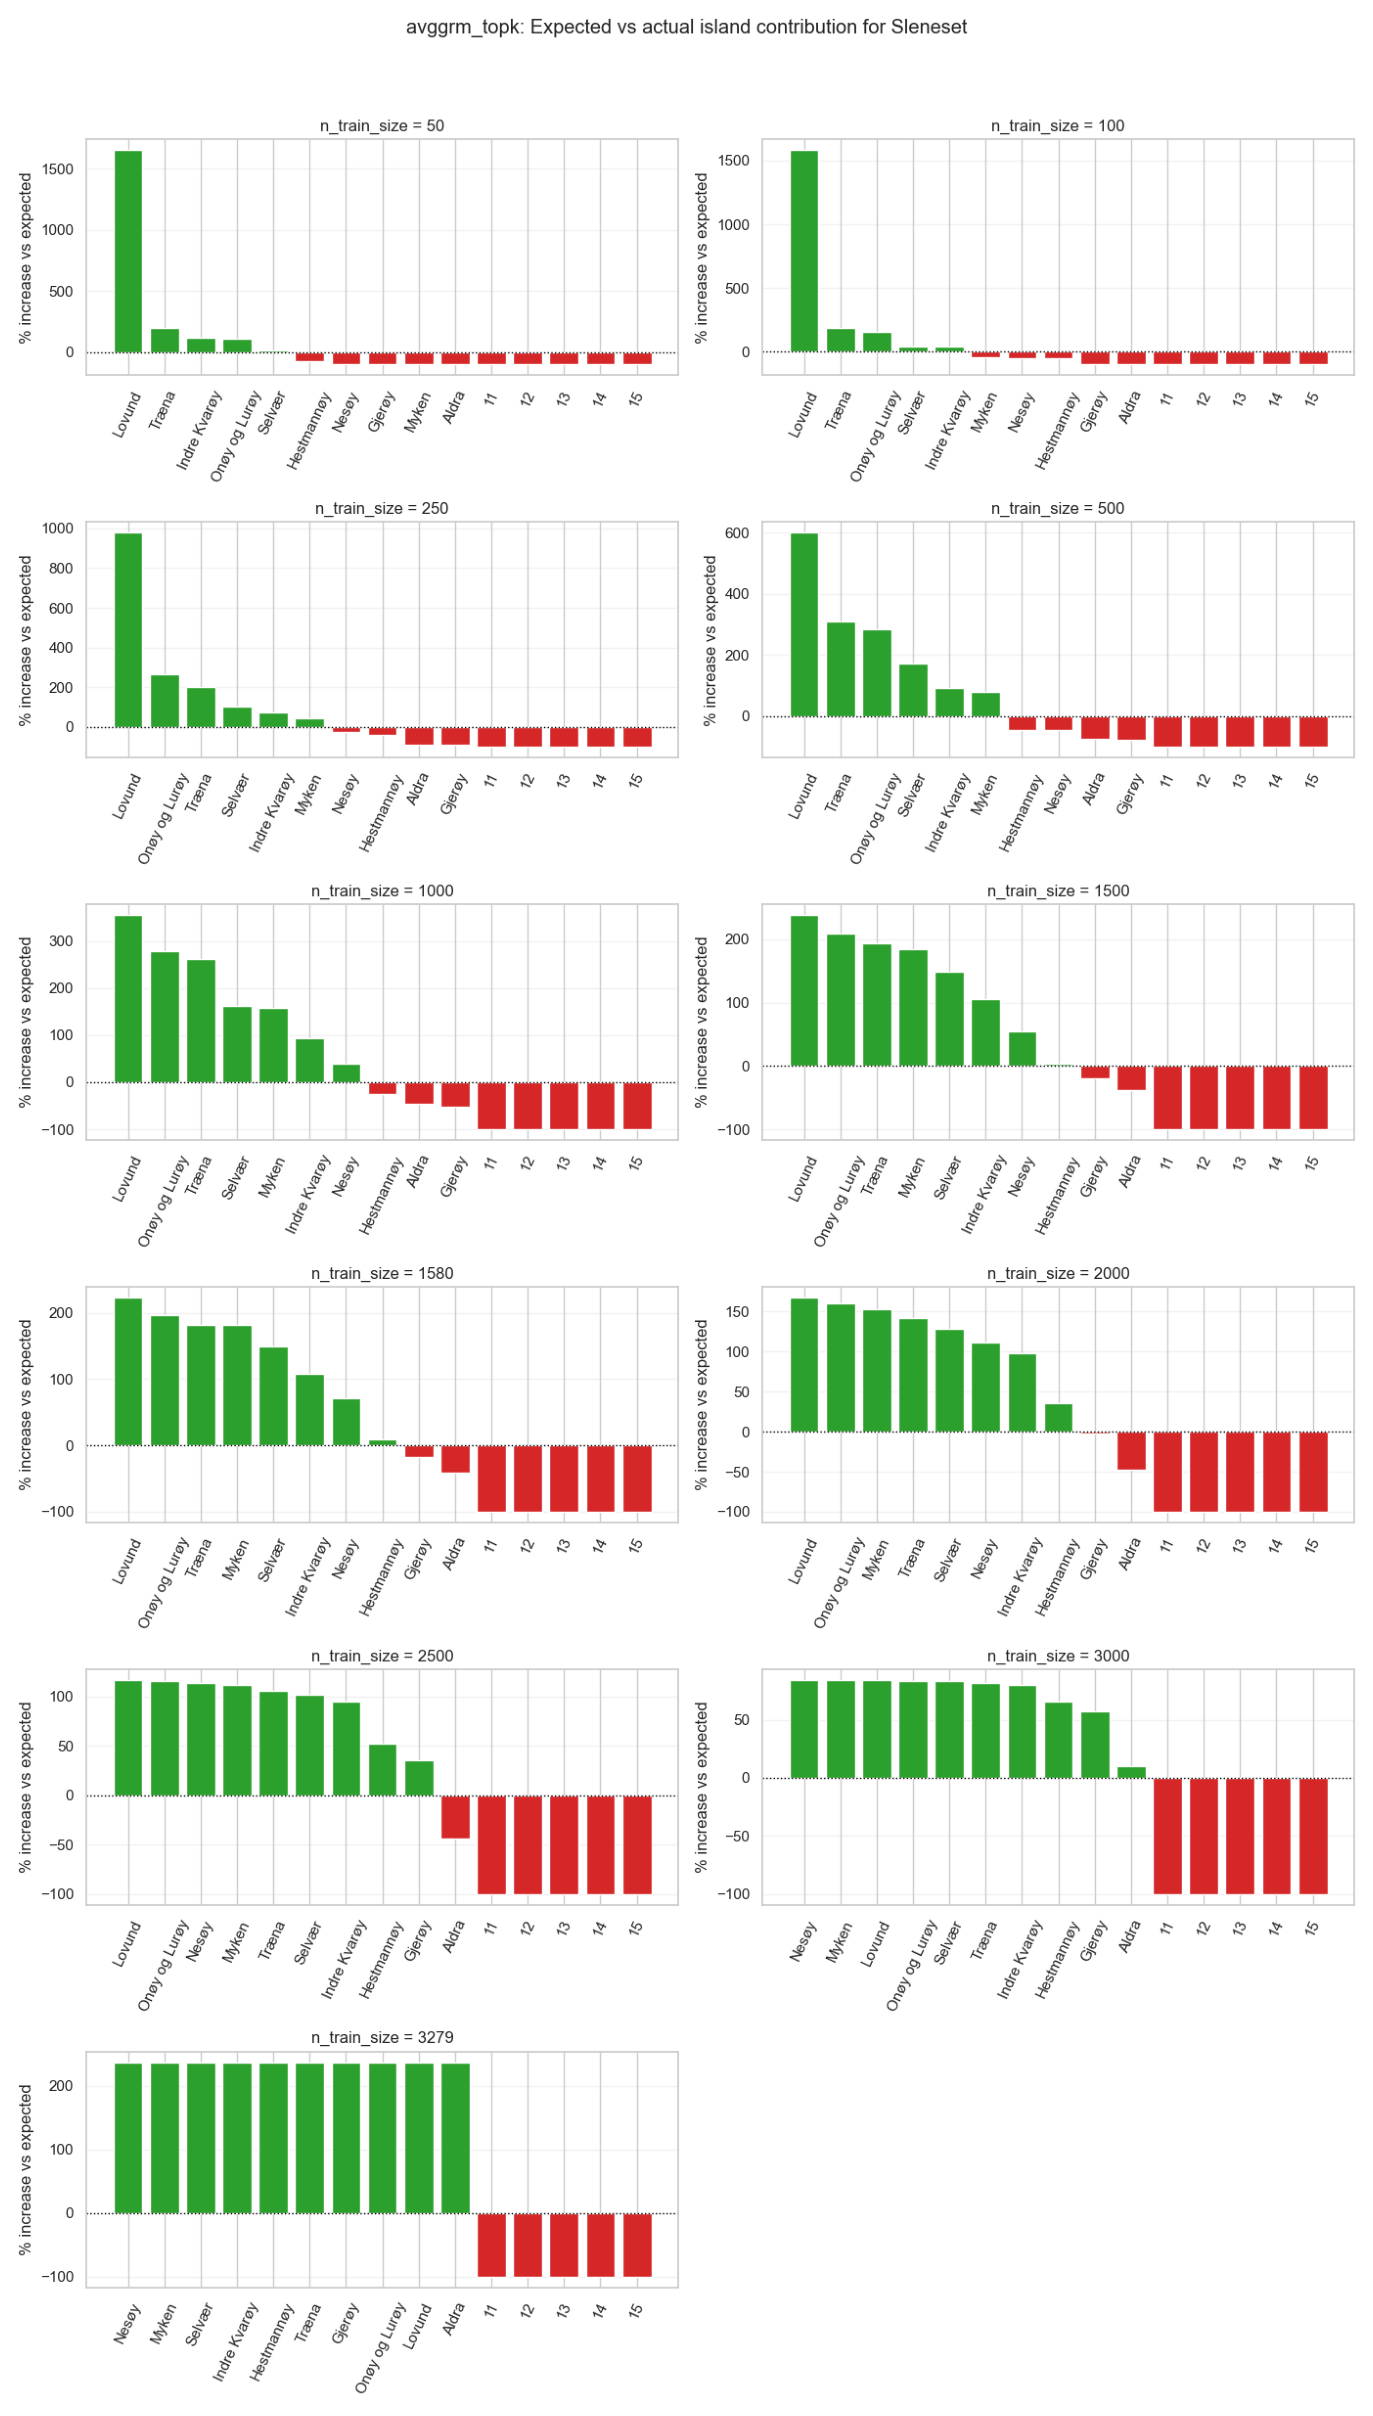

In [22]:
display_figure(PROJECT_ROOT / "figures" / "avggrm_v_pca.png")
display_figure(PROJECT_ROOT / "figures" / "pev_sel.png")
display_figure(PROJECT_ROOT / "figures" / "avggrm_sel.png")